C:\Users\toufi\AppData\Local\Temp\ipykernel_19548\1341881133.py:13: DtypeWarning: Columns (0: ts_g, 1: aplicom_g, 2: address_g, 3: advdata_g, 4: geom_g, 5: source_g) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("HAZARD_EVENT_WINDOWS.csv")


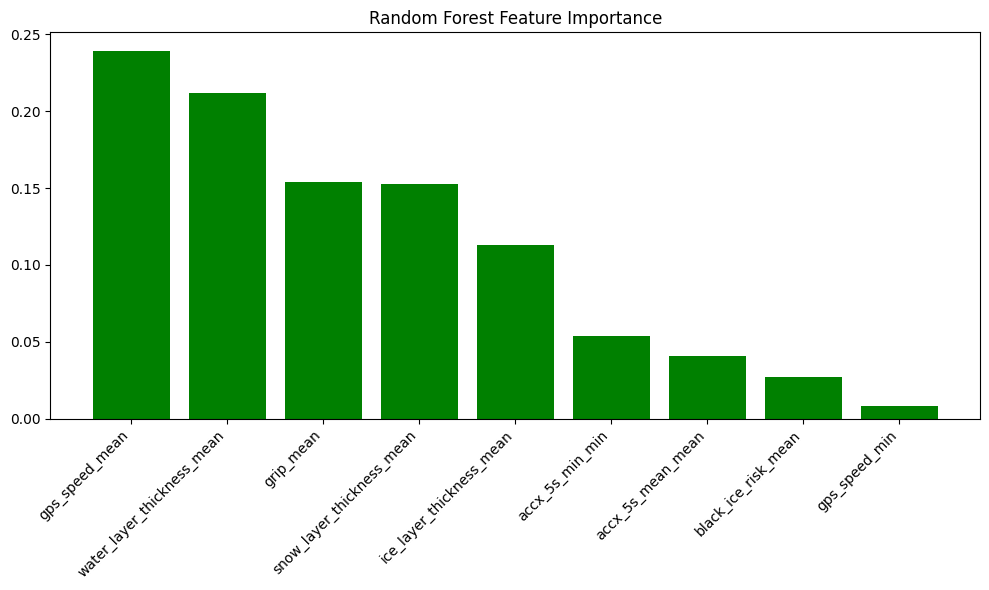

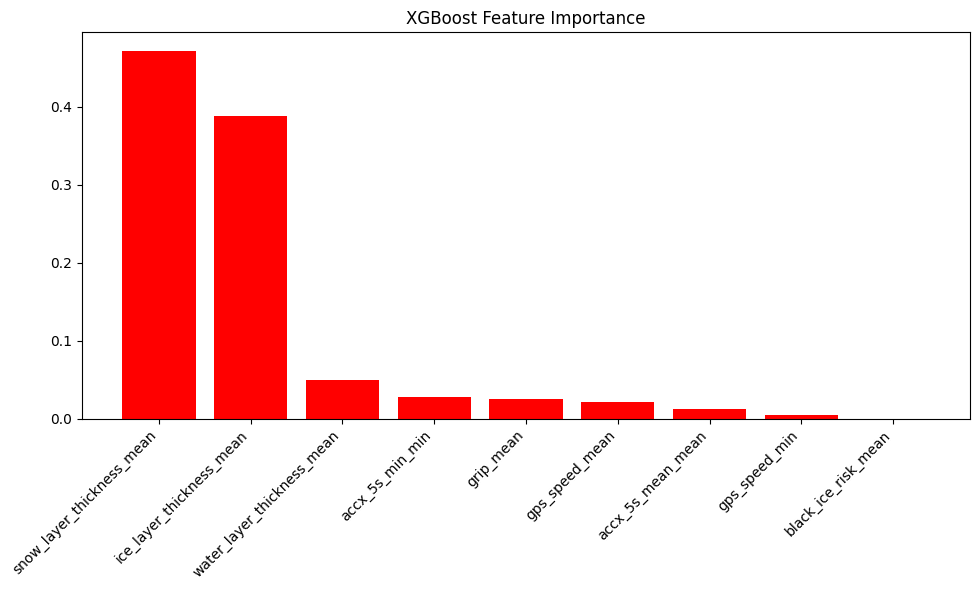

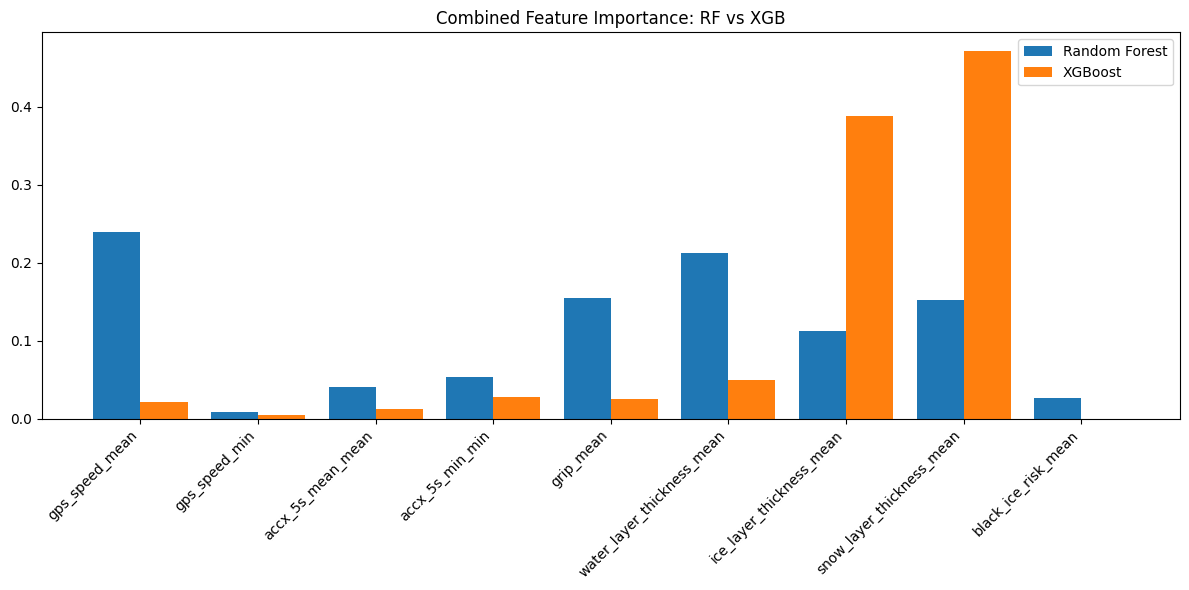

d:\Project\my files for project\ML-and-AI-Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


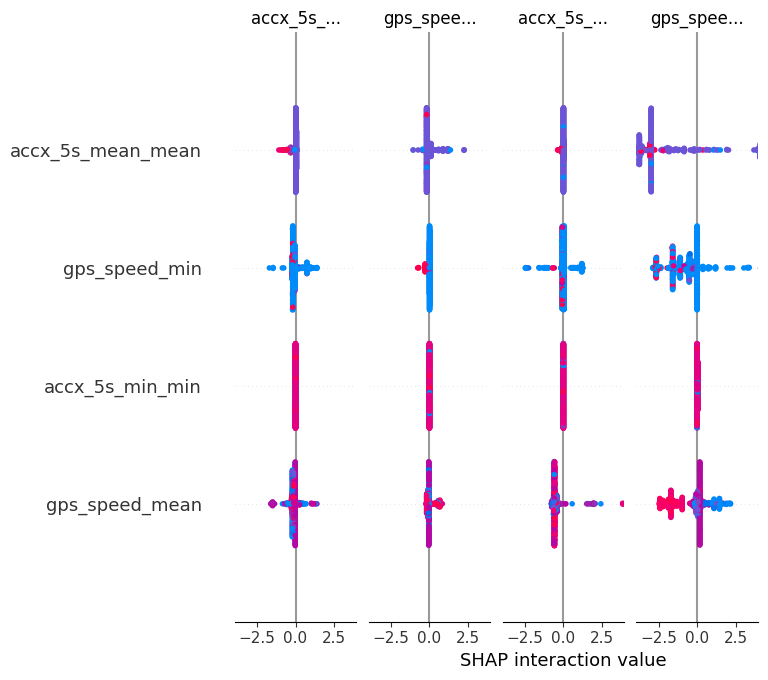


All interpretation plots saved inside: model_plots/


In [2]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Create output folder
os.makedirs("model_plots", exist_ok=True)

# ------------------------------------------------------------
# STEP 1 — LOAD DATASETS
# ------------------------------------------------------------

df = pd.read_csv("HAZARD_EVENT_WINDOWS.csv")
clusters = pd.read_csv("HAZARD_CLUSTER_TABLE.csv")

df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df["hazard_time"] = pd.to_datetime(df["hazard_time"], utc=True)

df["t_offset"] = (df["timestamp"] - df["hazard_time"]).dt.total_seconds()


# ------------------------------------------------------------
# STEP 2 — FEATURE ENGINEERING
# ------------------------------------------------------------

# GPS speed
df["lat_shift"] = df.groupby("hazard_id")["lat"].shift(1)
df["lon_shift"] = df.groupby("hazard_id")["lon"].shift(1)

def haversine(lat1, lon1, lat2, lon2):
    R = 6371000
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df["gps_speed"] = haversine(
    df["lat"], df["lon"], df["lat_shift"], df["lon_shift"]
)

# Rolling acc features
df["accx_5s_mean"] = df.groupby("hazard_id")["accx_g"].rolling(5, min_periods=1).mean().values
df["accx_5s_min"]  = df.groupby("hazard_id")["accx_g"].rolling(5, min_periods=1).min().values

# Black ice flag
df["black_ice_risk"] = (
    (df["surface_temperature"] < 2) &
    ((df["air_temperature"] - df["surface_temperature"]) > 0)
).astype(int)


# ------------------------------------------------------------
# STEP 3 — SELECT PRE-HAZARD WINDOW (−5s → −1s)
# ------------------------------------------------------------

pre_df = df[(df["t_offset"] >= -5) & (df["t_offset"] < 0)].copy()

# Aggregate features per hazard
pre_features = pre_df.groupby("hazard_id").agg({
    "gps_speed": ["mean", "min"],
    "accx_5s_mean": "mean",
    "accx_5s_min": "min",
    "grip": "mean",
    "water_layer_thickness": "mean",
    "ice_layer_thickness": "mean",
    "snow_layer_thickness": "mean",
    "black_ice_risk": "mean"
})

pre_features.columns = ["_".join(col) for col in pre_features.columns]
pre_features.reset_index(inplace=True)

# Merge cluster labels
pre_features = pre_features.merge(clusters[["hazard_id", "cluster"]], on="hazard_id", how="left")


# ------------------------------------------------------------
# STEP 4 — PREPARE ML DATA
# ------------------------------------------------------------

pre_features = pre_features.fillna(pre_features.median())

feature_cols = [c for c in pre_features.columns if c not in ["hazard_id", "cluster"]]
X = pre_features[feature_cols]
y = pre_features["cluster"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)


# ------------------------------------------------------------
# STEP 5 — TRAIN MODELS
# ------------------------------------------------------------

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42
)
rf_model.fit(X_train, y_train)

xgb_model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multi:softmax",
    num_class=len(y.unique()),
    eval_metric="mlogloss",
    random_state=42
)
xgb_model.fit(X_train, y_train)


# ------------------------------------------------------------
# STEP 6 — PLOT & SAVE FEATURE IMPORTANCE
# ------------------------------------------------------------

def save_rf_importance():
    importance = rf_model.feature_importances_
    idx = np.argsort(importance)[::-1]

    plt.figure(figsize=(10, 6))
    plt.bar(range(len(feature_cols)), importance[idx], color="green")
    plt.xticks(range(len(feature_cols)), [feature_cols[i] for i in idx], rotation=45, ha="right")
    plt.title("Random Forest Feature Importance")
    plt.tight_layout()
    plt.savefig("model_plots/rf_feature_importance.png")
    plt.show()


def save_xgb_importance():
    importance = xgb_model.feature_importances_
    idx = np.argsort(importance)[::-1]

    plt.figure(figsize=(10, 6))
    plt.bar(range(len(feature_cols)), importance[idx], color="red")
    plt.xticks(range(len(feature_cols)), [feature_cols[i] for i in idx], rotation=45, ha="right")
    plt.title("XGBoost Feature Importance")
    plt.tight_layout()
    plt.savefig("model_plots/xgb_feature_importance.png")
    plt.show()


def save_combined_importance():
    rf_imp = rf_model.feature_importances_
    xgb_imp = xgb_model.feature_importances_

    x = np.arange(len(feature_cols))

    plt.figure(figsize=(12, 6))
    plt.bar(x - 0.2, rf_imp, width=0.4, label="Random Forest")
    plt.bar(x + 0.2, xgb_imp, width=0.4, label="XGBoost")
    plt.xticks(x, feature_cols, rotation=45, ha="right")
    plt.legend()
    plt.title("Combined Feature Importance: RF vs XGB")
    plt.tight_layout()
    plt.savefig("model_plots/combined_feature_importance.png")
    plt.show()


# ------------------------------------------------------------
# STEP 7 — SHAP PLOT (Optional)
# ------------------------------------------------------------

def save_shap_summary():
    try:
        import shap
        explainer = shap.TreeExplainer(xgb_model)
        shap_values = explainer.shap_values(X_train)

        shap.summary_plot(shap_values, X_train, feature_names=feature_cols, show=False)
        plt.savefig("model_plots/shap_summary.png", bbox_inches='tight')
        plt.show()

    except Exception as e:
        print("\nSHAP not installed or failed:", e)


# ------------------------------------------------------------
# STEP 8 — RUN ALL VISUALIZATIONS
# ------------------------------------------------------------

save_rf_importance()
save_xgb_importance()
save_combined_importance()
save_shap_summary()

print("\nAll interpretation plots saved inside: model_plots/")